In [21]:
import MLFactor as ml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

params = ml.Params()

**🛠 Parameterdefinition:**
Alle Modell- und Backtestparameter sind in der Klasse `Params` definiert.

In [22]:
data = ml.Data(params)
data.get_data()

Data wird geladen...
Data geladen.


**📥 Daten:**
Es werden Kursdaten, Index-Gewichte, risikofreie Zinsen (10Y US Treasury) und der VIX geladen.


In [23]:
factors = ml.Factors(data, params)
factors.get_factor_scores()

Factor Ränge werden berechnet...


100%|██████████| 5013/5013 [00:15<00:00, 320.38it/s]


Factor Ränge berechnet.


**📈 Faktorsignale:**
- 12-Monats-Performance (Momentum)
- 12-Monats-Volatilität (Low Volatility)
- Berechnung von Quintils-Ranks zur späteren Gewichtung


Model wird trainiert...


100%|██████████| 218/218 [00:02<00:00, 73.53it/s]


ML-Modell gespeichert.
Model trainiert.


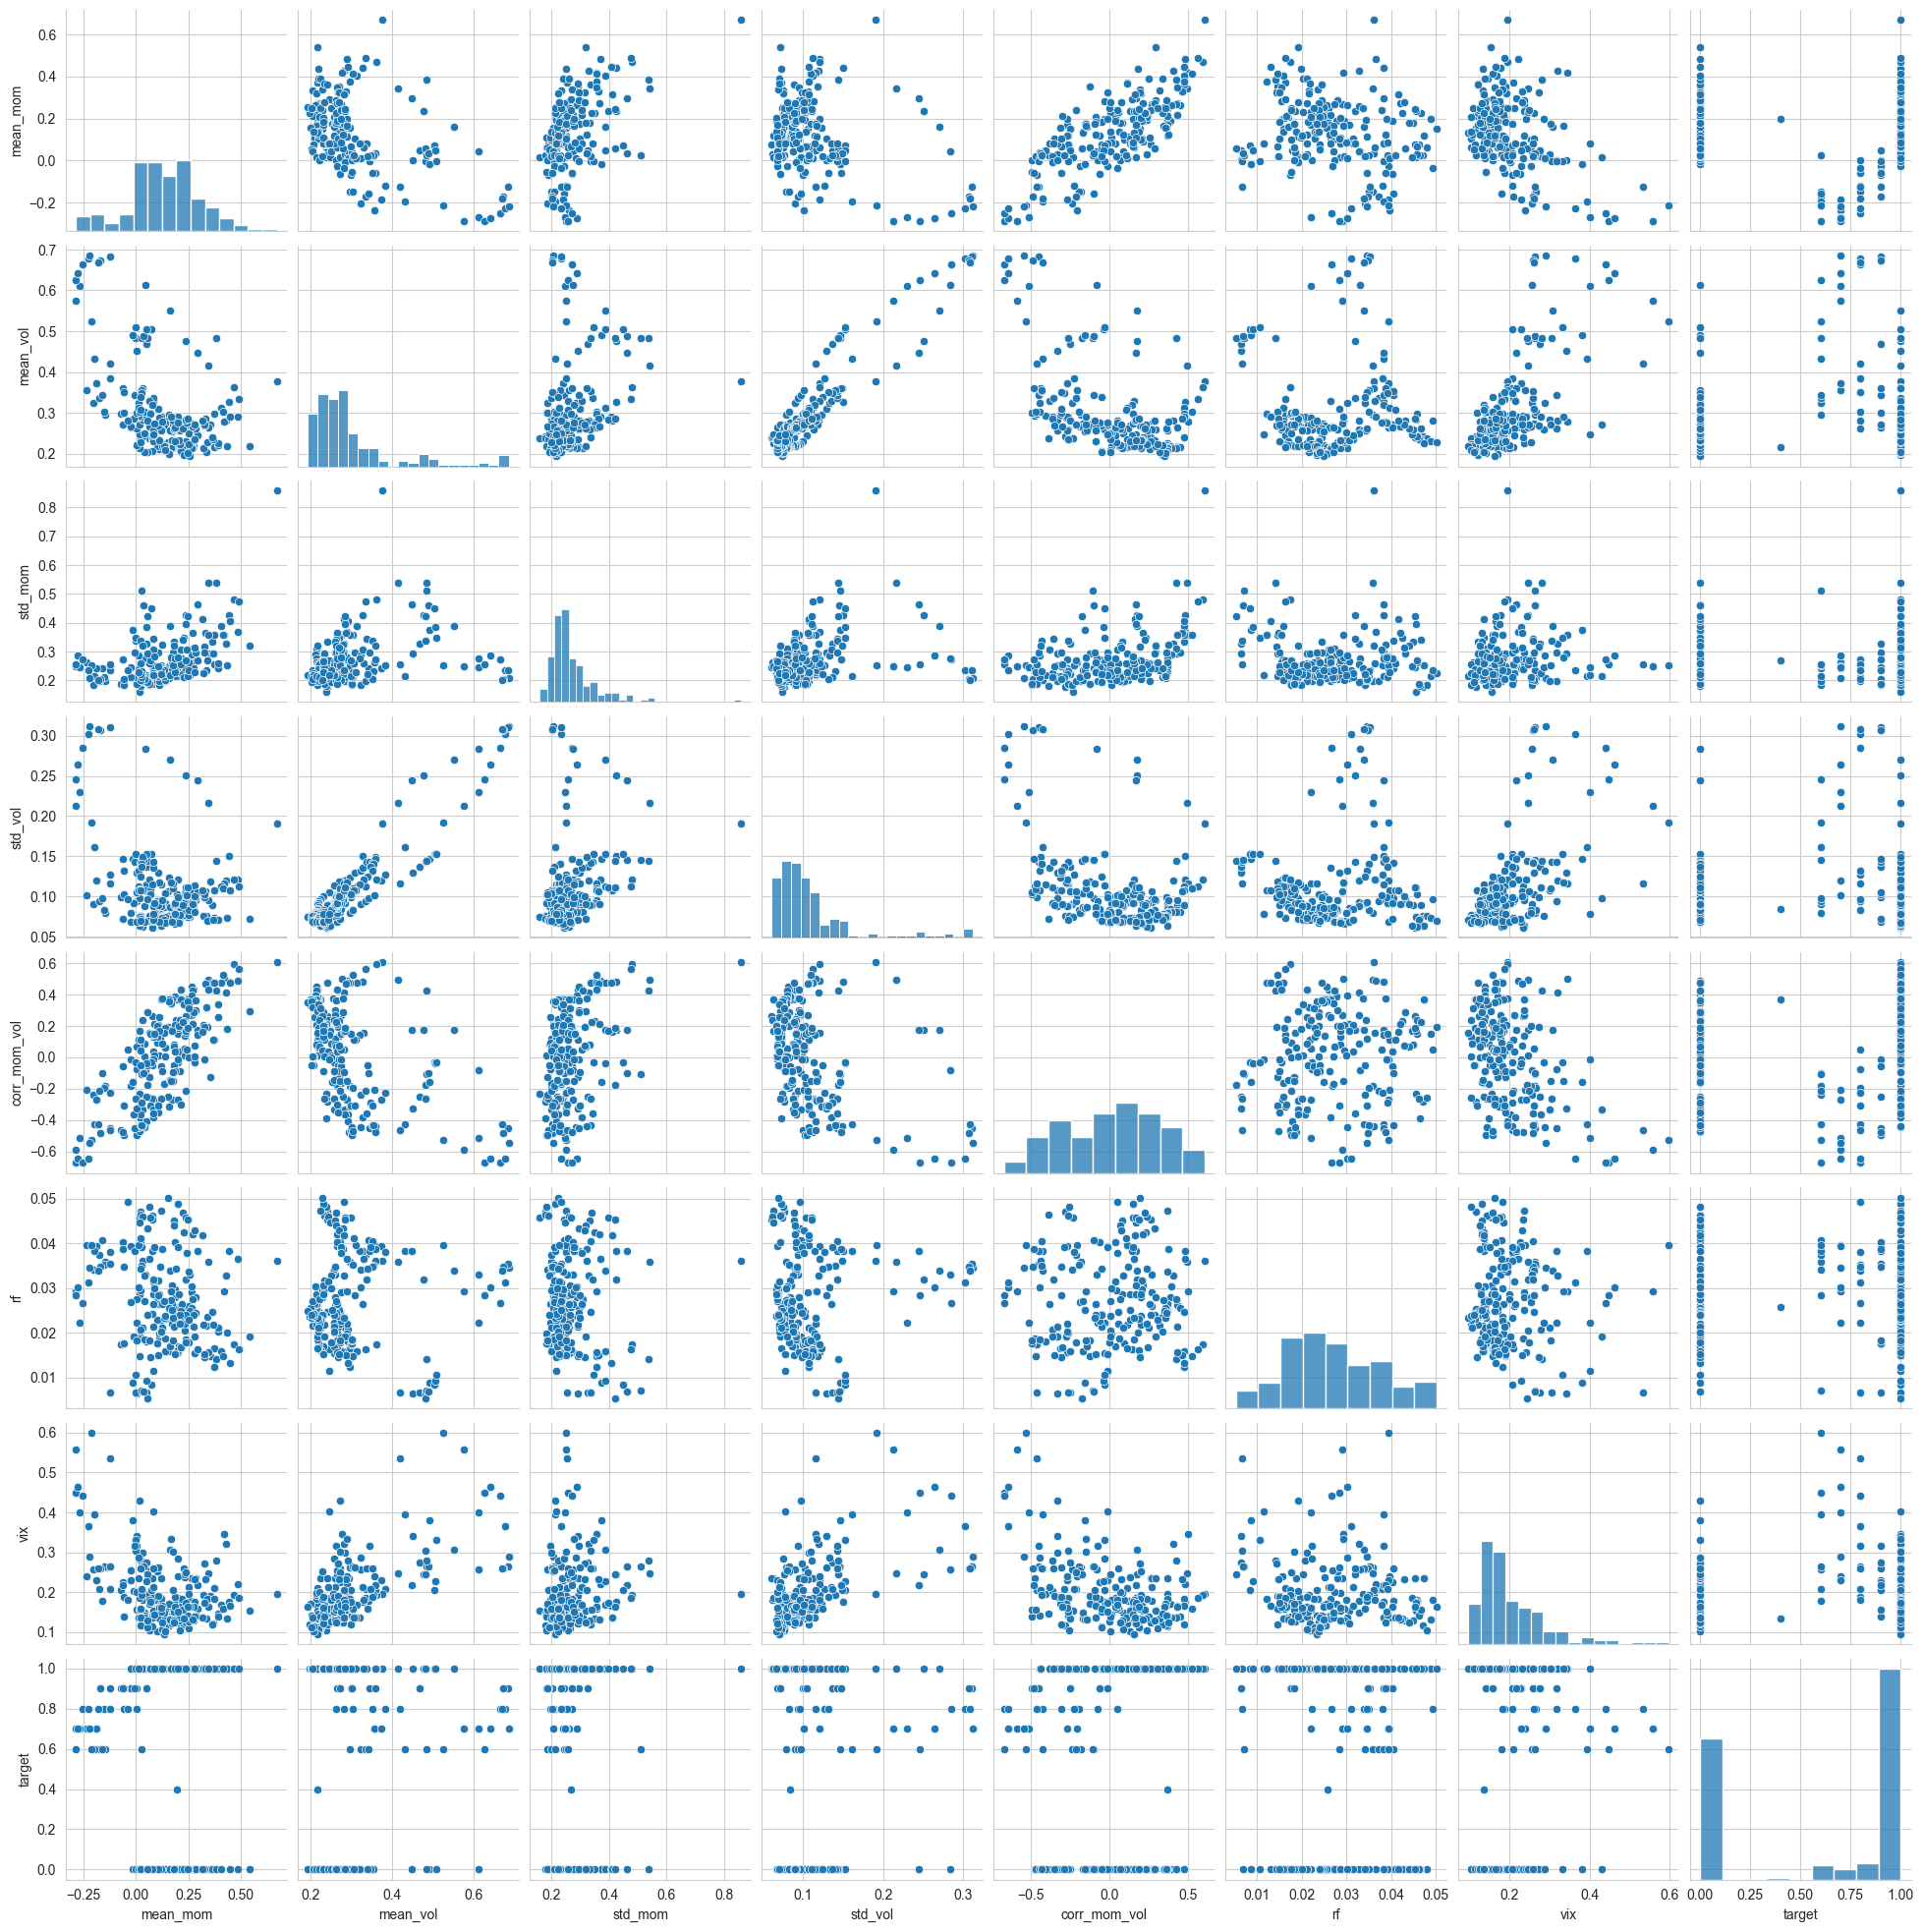

In [24]:
ml_model = ml.MLModel(factors, data, params)
ml_model.train_model()

**🧠 RandomForest-Modell zur Faktorgewicht-Bestimmung:**
- Target: optimale Gewichtung von Momentum vs. Volatilität
- Features: Mittelwert, Standardabweichung, Korrelation, Zinsen, VIX


C:\Users\v011836\AppData\Local\Temp\ipykernel_6672\3061174664.py:3: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\PROD_VENV\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


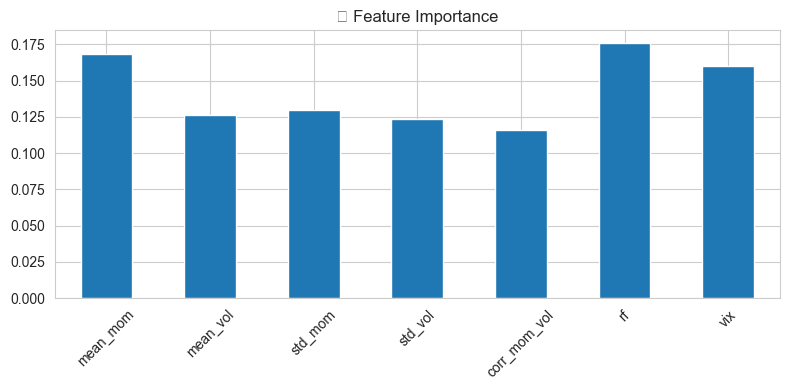

In [25]:
ml_model.df_importance.plot(kind="bar", legend=False, title="🎯 Feature Importance", figsize=(8, 4))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [26]:
ml_model.feature_stats


,F-Score,p-Value
mean_mom,0.420869,0.517193
mean_vol,1.103857,0.294595
std_mom,0.016623,0.897534
std_vol,0.561833,0.454338
corr_mom_vol,0.060836,0.805413
rf,1.686935,0.195390
vix,2.422327,0.121081


**🔍 Feature Analyse:**
Die Bedeutung einzelner Features für die ML-basierte Gewichtung wird per `feature_importances_` sowie F-Score/P-Value gezeigt.


In [ ]:
factors.get_factor_weight()
factors.get_stock_weights()

backtest = ml.Backtest(data, factors, params)
backtest.run_backtest()


ML factor model wird angewendet, um Gewichte zu erhalten...


 36%|███▌      | 1723/4761 [00:16<00:27, 110.31it/s]

In [ ]:
backtest.bt_performance.style.background_gradient(cmap="YlGnBu")

In [ ]:
backtest.df_portfolio_returns[["ML_CUM", "5050_CUM", "AVG_ML_CUM"]].plot(figsize=(10, 5), title="📈 Kumulative Renditevergleich")
plt.ylabel("Kumulierte Rendite")
plt.xlabel("Datum")
plt.tight_layout()
plt.show()